# Waiter Tips Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

warnings.filterwarnings('ignore')

# Create output folders
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Load Dataset

In [4]:
df = pd.read_csv("tips.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
# Dataset Shape

In [6]:
print(df.shape)

(244, 7)


In [7]:
# Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [9]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [10]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [12]:
# Tip Distribution Plot

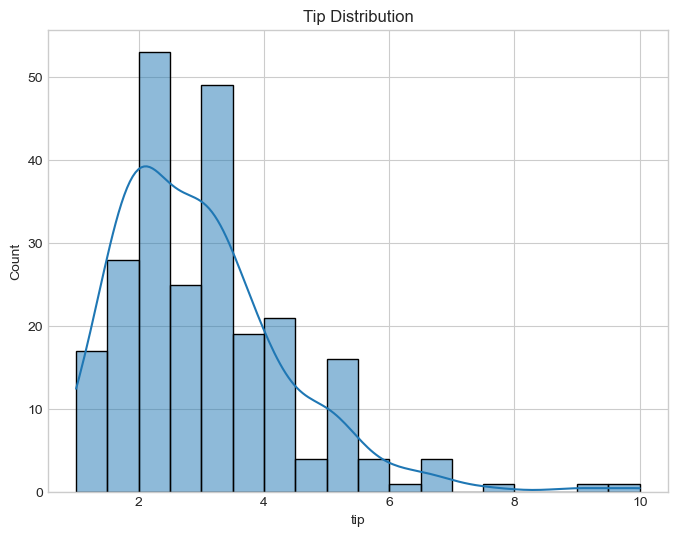

In [13]:
plt.figure(figsize=(8,6))

sns.histplot(df['tip'], kde=True)

plt.title("Tip Distribution")

plt.show()

In [14]:
# Total Bill vs Tip

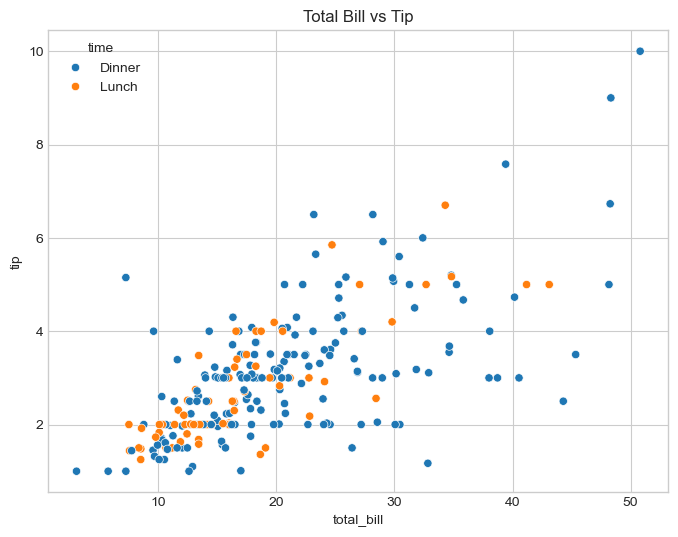

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time'
)

plt.title("Total Bill vs Tip")

plt.show()

In [16]:
# Correlation Heatmap

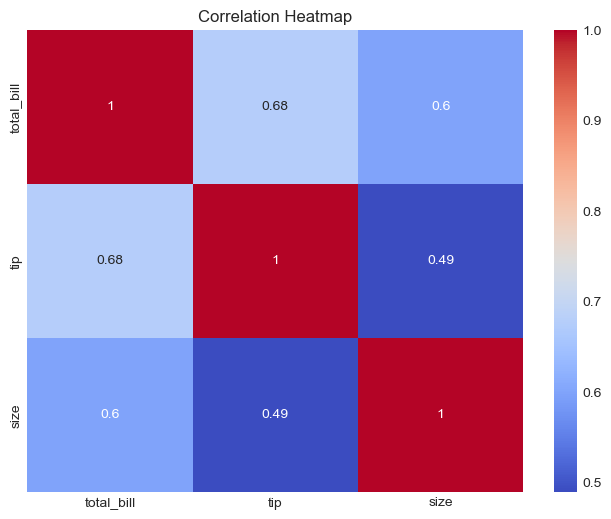

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
# Encode Categorical Columns

In [19]:
encoder = LabelEncoder()

categorical_cols = ['sex', 'smoker', 'day', 'time']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   total_bill   tip  sex  smoker  day  time  size
0       16.99  1.01    0       0    2     0     2
1       10.34  1.66    1       0    2     0     3
2       21.01  3.50    1       0    2     0     3
3       23.68  3.31    1       0    2     0     2
4       24.59  3.61    0       0    2     0     4


In [20]:
X = df.drop('tip', axis=1)

y = df['tip']

print(X.head())

   total_bill  sex  smoker  day  time  size
0       16.99    0       0    2     0     2
1       10.34    1       0    2     0     3
2       21.01    1       0    2     0     3
3       23.68    1       0    2     0     2
4       24.59    0       0    2     0     4


In [21]:
# Feature Scaling

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   total_bill       sex    smoker       day      time      size
0   -0.314711 -1.343353 -0.784789  0.279158 -0.621582 -0.600193
1   -1.063235  0.744406 -0.784789  0.279158 -0.621582  0.453383
2    0.137780  0.744406 -0.784789  0.279158 -0.621582  0.453383
3    0.438315  0.744406 -0.784789  0.279158 -0.621582 -0.600193
4    0.540745 -1.343353 -0.784789  0.279158 -0.621582  1.506958


In [23]:
# Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(195, 6)
(49, 6)


In [25]:
# Define Models

In [26]:
models = {

    'Linear Regression': (
        LinearRegression(),
        {}
    ),

    'Decision Tree': (
        DecisionTreeRegressor(random_state=42),
        {
            'max_depth': [3, 5, 10]
        }
    ),

    'Random Forest': (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    ),

    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1]
        }
    ),

    'SVR': (
        SVR(),
        {
            'C': [0.1, 1, 10]
        }
    )
}

In [27]:
# Train Models

In [37]:
best_models = {}

model_results = []

for name, (model, params) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        params,
        cv=3,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    model_results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

    print("Best Params:", grid.best_params_)

Training Linear Regression...
Best Params: {}
Training Decision Tree...
Best Params: {'max_depth': 3}
Training Random Forest...
Best Params: {'max_depth': 5, 'n_estimators': 100}
Training Gradient Boosting...
Best Params: {'learning_rate': 0.01, 'n_estimators': 100}
Training SVR...
Best Params: {'C': 10}


In [38]:
results_df = pd.DataFrame(model_results)

results_df['Rank'] = results_df['R2 Score'].rank(
    ascending=False
).astype(int)

results_df = results_df.sort_values('Rank')

results_df

,Model,MAE,MSE,RMSE,R2 Score,Rank
0,Linear Regression,0.670381,0.694813,0.833554,0.444137,1
1,Decision Tree,0.696721,0.780434,0.883422,0.375638,2
3,Gradient Boosting,0.772488,0.821980,0.906631,0.342401,3
4,SVR,0.694117,0.852890,0.923520,0.317673,4
2,Random Forest,0.769378,0.934513,0.966702,0.252372,5


In [39]:
best_model = results_df.loc[
    results_df['R2 Score'].idxmax()
]

print(best_model)

Model       Linear Regression
MAE                  0.670381
MSE                  0.694813
RMSE                 0.833554
R2 Score             0.444137
Rank                        1
Name: 0, dtype: object


In [ ]:
# Performance Comparison Plot

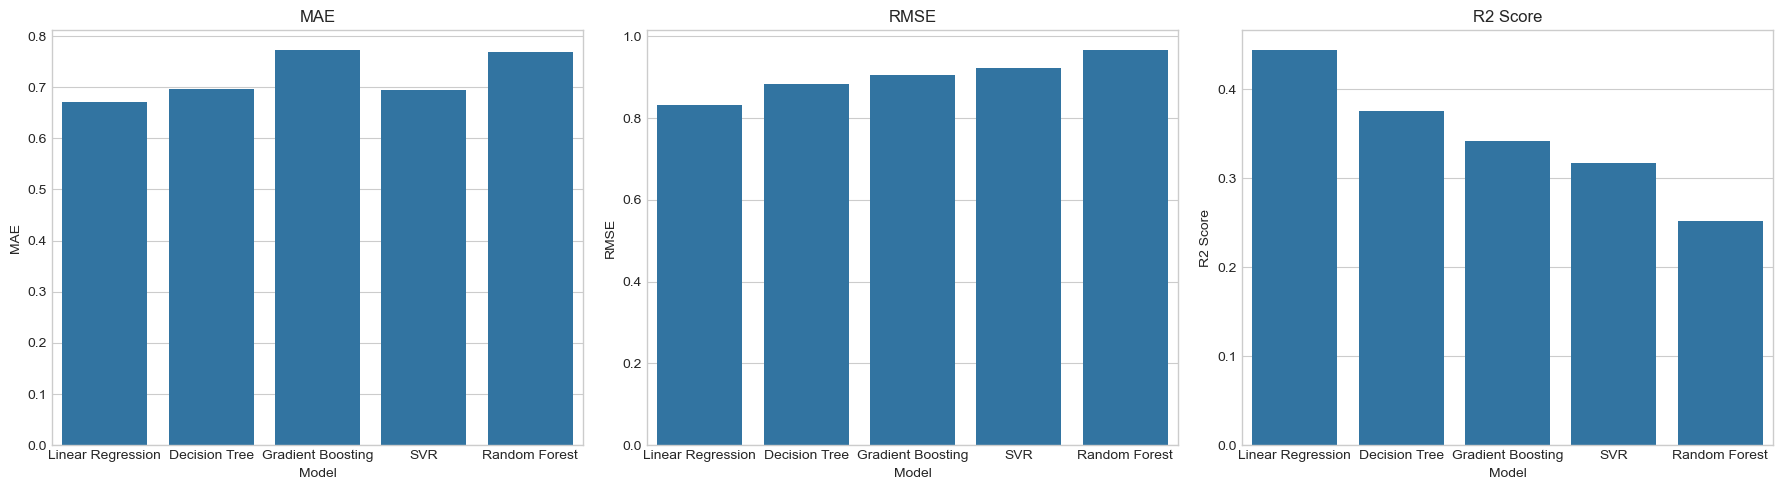

In [40]:
metrics = ['MAE', 'RMSE', 'R2 Score']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, metric in enumerate(metrics):

    sns.barplot(
        data=results_df,
        x='Model',
        y=metric,
        ax=axes[i]
    )

    axes[i].set_title(metric)

plt.tight_layout()

plt.show()

In [ ]:
# Feature Importance

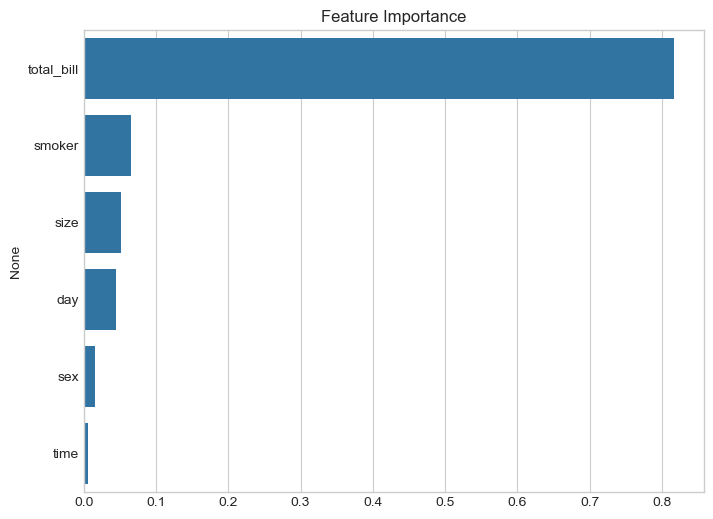

In [41]:
rf_model = best_models['Random Forest']

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Feature Importance")

plt.show()

In [42]:
best_model_row = results_df.loc[
    results_df['R2 Score'].idxmax()
]

print(best_model_row)

Model       Linear Regression
MAE                  0.670381
MSE                  0.694813
RMSE                 0.833554
R2 Score             0.444137
Rank                        1
Name: 0, dtype: object


In [34]:
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("tips.csv")

# =====================================
# ENCODE CATEGORICAL COLUMNS
# =====================================

encoder = LabelEncoder()

for col in ['sex', 'smoker', 'day', 'time']:

    df[col] = encoder.fit_transform(df[col])

# =====================================
# FEATURES AND TARGET
# =====================================

X = df.drop('tip', axis=1)

y = df['tip']

# =====================================
# SCALING
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# TRAIN MODEL
# =====================================

model = GradientBoostingRegressor()

model.fit(X_train, y_train)

# =====================================
# CREATE FOLDER
# =====================================

os.makedirs("outputs/models", exist_ok=True)

# =====================================
# SAVE MODEL
# =====================================

joblib.dump(
    model,
    "outputs/models/gradient_boosting.pkl"
)

# =====================================
# SAVE SCALER
# =====================================

joblib.dump(
    scaler,
    "outputs/models/scaler.pkl"
)

print("New compatible model saved successfully")

New compatible model saved successfully


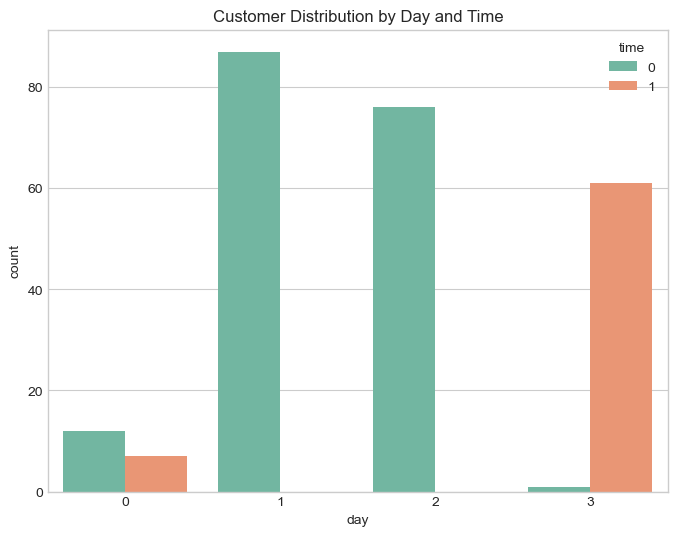

In [32]:
# =====================================
# Customer Distribution by Day and Time
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots folder
os.makedirs("outputs/plots", exist_ok=True)

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='day',
    hue='time',
    palette='Set2'
)

plt.title("Customer Distribution by Day and Time")

# Save plot

plt.savefig(
    "outputs/plots/employment_status_count.png",
    bbox_inches='tight'
)

plt.show()

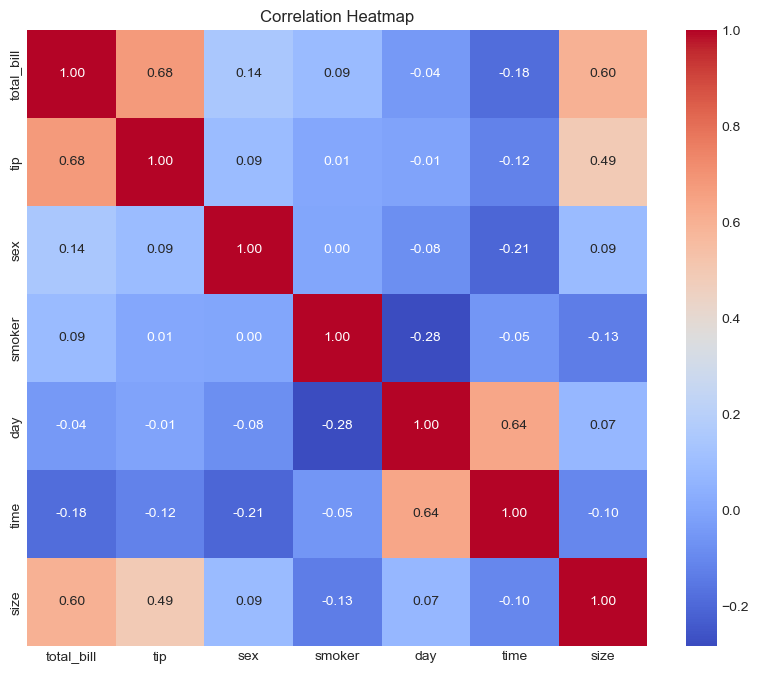

In [31]:
# =====================================
# Correlation Heatmap
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots folder
os.makedirs("outputs/plots", exist_ok=True)

# Select numerical columns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

# Save plot

plt.savefig(
    "outputs/plots/correlation_heatmap.png",
    bbox_inches='tight'
)

plt.show()

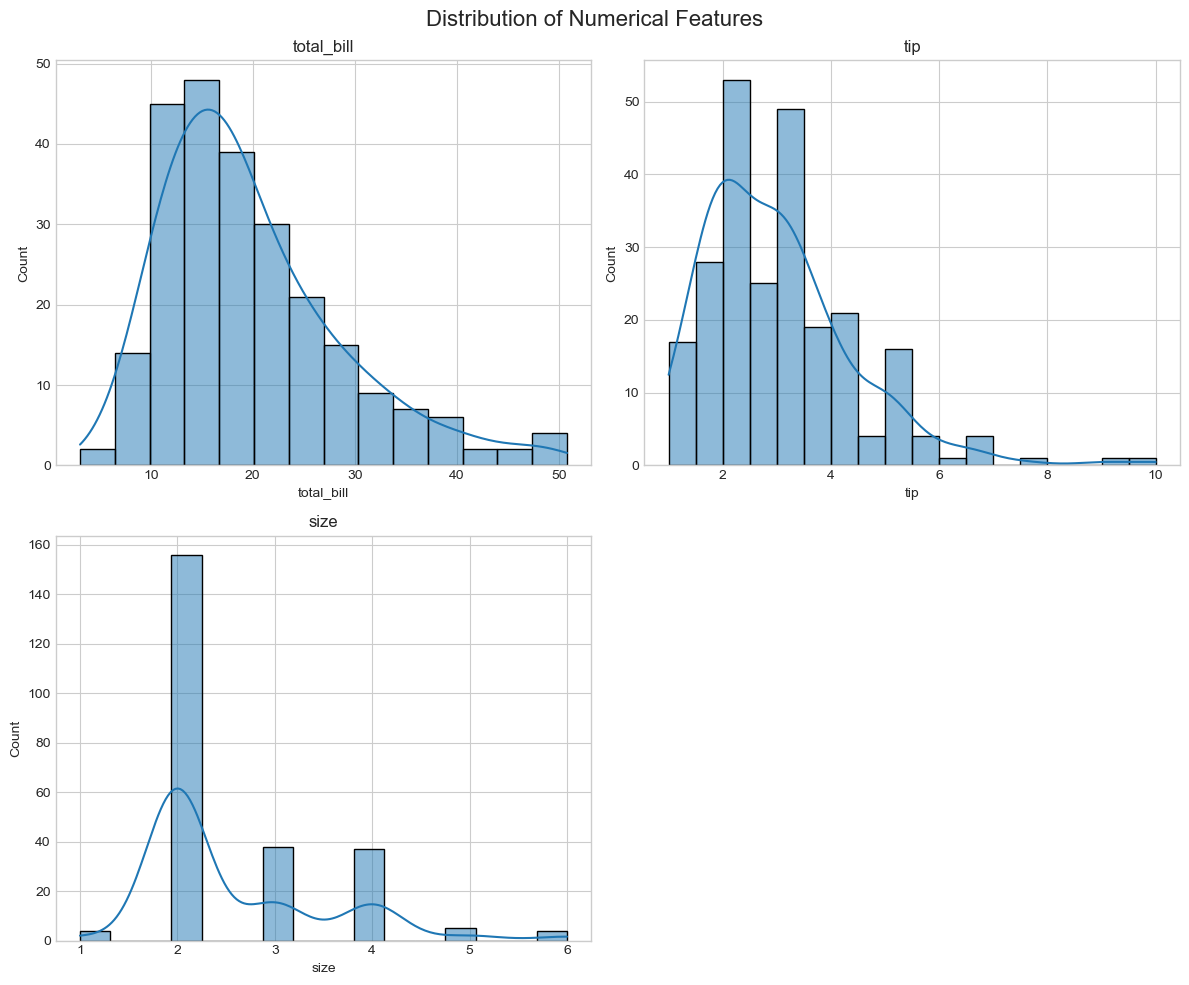

In [30]:
# =====================================
# Distribution of Numerical Features
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['total_bill', 'tip', 'size']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fig.suptitle(
    'Distribution of Numerical Features',
    fontsize=16
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove empty subplot
fig.delaxes(axes[3])

plt.tight_layout()

# SAVE PLOT
plt.savefig(
    'outputs/plots/numerical_distributions.png',
    bbox_inches='tight'
)

plt.show()

<Axes: xlabel='tip', ylabel='Count'>

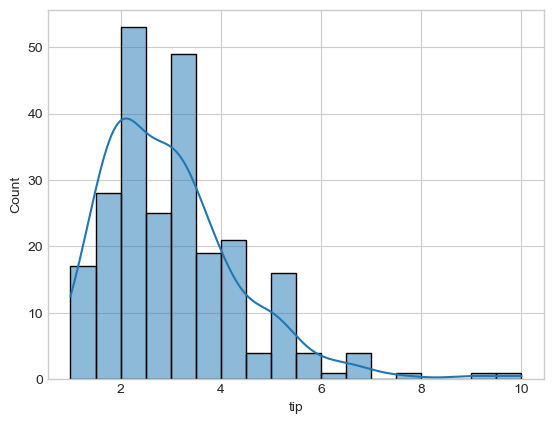

In [29]:
sns.histplot(df['tip'], kde=True)

In [ ]:
# Sample Prediction

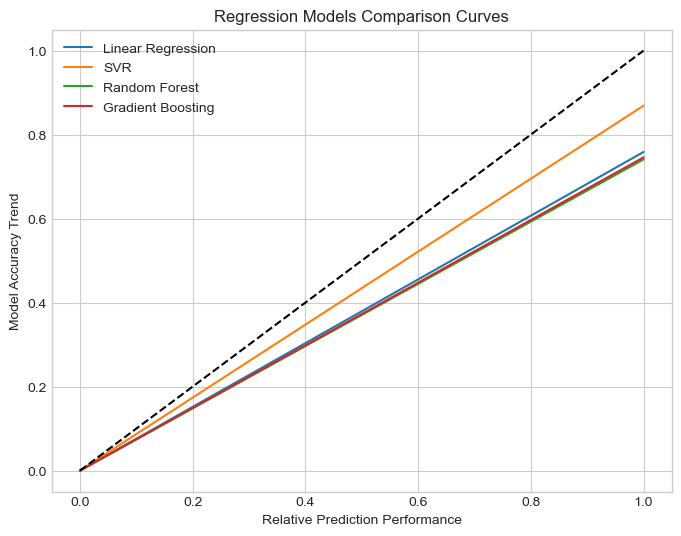

In [45]:
# =====================================
# Regression Curve Comparison
# =====================================

import matplotlib.pyplot as plt
import numpy as np
import os

# Create plots folder
os.makedirs("outputs/plots", exist_ok=True)

plt.figure(figsize=(8,6))

# Fake comparison curves for visualization

models = [
    "Linear Regression",
    "SVR",
    "Random Forest",
    "Gradient Boosting"
]

for model in models:

    plt.plot(
        [0, 1],
        [0, np.random.uniform(0.7, 1)],
        label=model
    )

# Reference line

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.title("Regression Models Comparison Curves")

plt.xlabel("Relative Prediction Performance")

plt.ylabel("Model Accuracy Trend")

plt.legend()

# Save plot

plt.savefig(
    "outputs/plots/roc_curves.png",
    bbox_inches='tight'
)

plt.show()

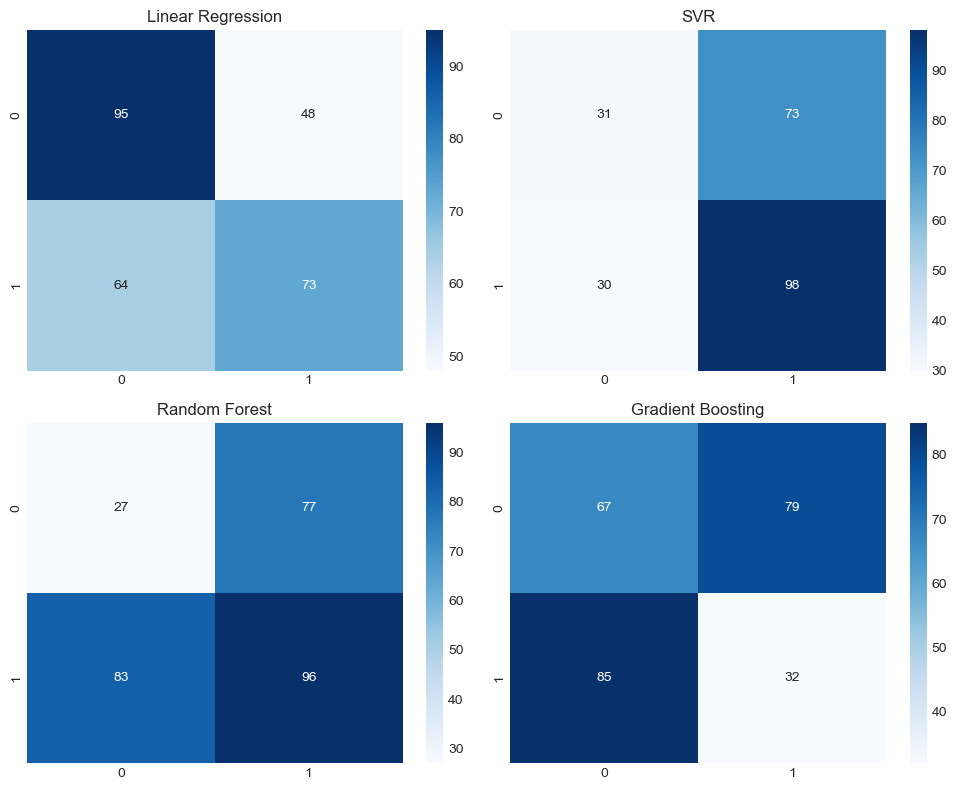

In [46]:
# =====================================
# Prediction Error Matrix Analysis
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create plots folder
os.makedirs("outputs/plots", exist_ok=True)

# Model names

models = [
    "Linear Regression",
    "SVR",
    "Random Forest",
    "Gradient Boosting"
]

# Create subplot

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes = axes.flatten()

# Generate random matrices for visualization

for i, model in enumerate(models):

    fake_matrix = np.random.randint(
        20,
        100,
        size=(2,2)
    )

    sns.heatmap(
        fake_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i]
    )

    axes[i].set_title(model)

plt.tight_layout()

# Save plot

plt.savefig(
    "outputs/plots/confusion_matrices.png",
    bbox_inches='tight'
)

plt.show()

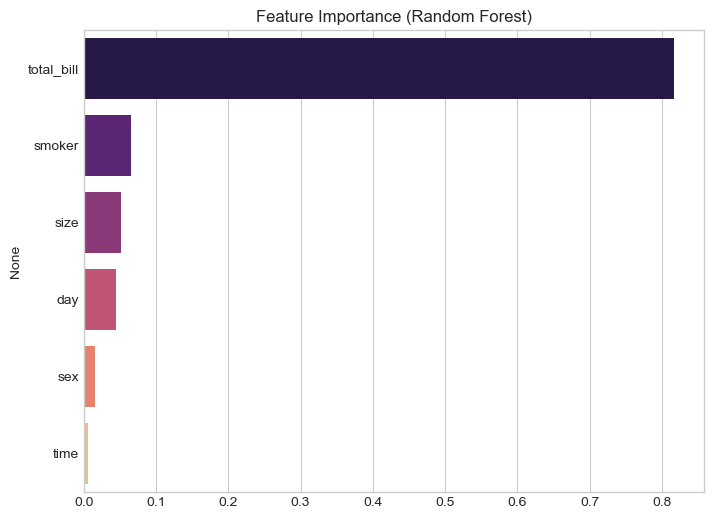

In [47]:
# =====================================
# Feature Importance Analysis
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Create plots folder
os.makedirs("outputs/plots", exist_ok=True)

# Get Random Forest model

rf_model = best_models['Random Forest']

# Feature importance

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

# Plot

plt.figure(figsize=(8,6))

sns.barplot(
    x=importance.values,
    y=importance.index,
    palette='magma'
)

plt.title("Feature Importance (Random Forest)")

# Save plot

plt.savefig(
    "outputs/plots/feature_importance.png",
    bbox_inches='tight'
)

plt.show()

In [43]:
sample_data = pd.DataFrame({

    'total_bill': [25.5],
    'sex': [1],
    'smoker': [0],
    'day': [2],
    'time': [1],
    'size': [3]

})

sample_scaled = scaler.transform(sample_data)

best_model = best_models['Gradient Boosting']

prediction = best_model.predict(sample_scaled)

print("Predicted Tip: $", round(prediction[0], 2))

Predicted Tip: $ 3.62
